import libraries

In [72]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
import difflib
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import re
from nltk.tokenize import word_tokenize
import joblib


load and analyse data

In [43]:
data=pd.read_csv("movies.csv")

In [44]:
data.head()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


In [45]:
data.tail()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
4798,4798,220000,Action Crime Thriller,NaN,9367,united states\u2013mexico barrier legs arms pa...,es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,...,81.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,"He didn't come looking for trouble, but troubl...",El Mariachi,6.6,238,Carlos Gallardo Jaime de Hoyos Peter Marquardt...,"[{'name': 'Robert Rodriguez', 'gender': 0, 'de...",Robert Rodriguez
4799,4799,9000,Comedy Romance,NaN,72766,NaN,en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,...,85.0,[],Released,A newlywed couple's honeymoon is upended by th...,Newlyweds,5.9,5,Edward Burns Kerry Bish\u00e9 Marsha Dietlein ...,"[{'name': 'Edward Burns', 'gender': 2, 'depart...",Edward Burns
4800,4800,0,Comedy Drama Romance TV Movie,http://www.hallmarkchannel.com/signedsealeddel...,231617,date love at first sight narration investigati...,en,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...",1.444476,...,120.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,"Signed, Sealed, Delivered",7.0,6,Eric Mabius Kristin Booth Crystal Lowe Geoff G...,"[{'name': 'Carla Hetland', 'gender': 0, 'depar...",Scott Smith
4801,4801,0,NaN,http://shanghaicalling.com/,126186,NaN,en,Shanghai Calling,When ambitious New York attorney Sam is sent t...,0.857008,...,98.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,A New Yorker in Shanghai,Shanghai Calling,5.7,7,Daniel Henney Eliza Coupe Bill Paxton Alan Ruc...,"[{'name': 'Daniel Hsia', 'gender': 2, 'departm...",Daniel Hsia
4802,4802,0,Documentary,NaN,25975,obsession camcorder crush dream girl,en,My Date with Drew,Ever since the second grade when he first saw ...,1.929883,...,90.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,My Date with Drew,6.3,16,Drew Barrymore Brian Herzlinger Corey Feldman ...,"[{'name': 'Clark Peterson', 'gender': 2, 'depa...",Brian Herzlinger


In [46]:
data.shape


(4803, 24)

In [47]:
data.describe()

,index,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4803.000000,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2401.000000,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,1386.651002,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,1200.500000,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,2401.000000,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,3601.500000,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,4802.000000,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [48]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   str    
 3   homepage              1712 non-null   str    
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   str    
 6   original_language     4803 non-null   str    
 7   original_title        4803 non-null   str    
 8   overview              4800 non-null   str    
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   str    
 11  production_countries  4803 non-null   str    
 12  release_date          4802 non-null   str    
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15  spoken_languages      4803 non-n

In [49]:
data.isnull().sum()

index                      0
budget                     0
genres                    28
homepage                3091
id                         0
keywords                 412
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                      43
crew                       0
director                  30
dtype: int64

In [50]:
features=data[['genres','keywords','overview','tagline','cast','director']]

In [51]:
features.head()

,genres,keywords,overview,tagline,cast,director
0,Action Adventure Fantasy Science Fiction,culture clash future space war space colony so...,"In the 22nd century, a paraplegic Marine is di...",Enter the World of Pandora.,Sam Worthington Zoe Saldana Sigourney Weaver S...,James Cameron
1,Adventure Fantasy Action,ocean drug abuse exotic island east india trad...,"Captain Barbossa, long believed to be dead, ha...","At the end of the world, the adventure begins.",Johnny Depp Orlando Bloom Keira Knightley Stel...,Gore Verbinski
2,Action Adventure Crime,spy based on novel secret agent sequel mi6,A cryptic message from Bond’s past sends him o...,A Plan No One Escapes,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,Sam Mendes
3,Action Crime Drama Thriller,dc comics crime fighter terrorist secret ident...,Following the death of District Attorney Harve...,The Legend Ends,Christian Bale Michael Caine Gary Oldman Anne ...,Christopher Nolan
4,Action Adventure Science Fiction,based on novel mars medallion space travel pri...,"John Carter is a war-weary, former military ca...","Lost in our world, found in another.",Taylor Kitsch Lynn Collins Samantha Morton Wil...,Andrew Stanton


In [52]:
features.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   genres    4775 non-null   str  
 1   keywords  4391 non-null   str  
 2   overview  4800 non-null   str  
 3   tagline   3959 non-null   str  
 4   cast      4760 non-null   str  
 5   director  4773 non-null   str  
dtypes: str(6)
memory usage: 225.3 KB


In [53]:
features.isnull().sum()

genres       28
keywords    412
overview      3
tagline     844
cast         43
director     30
dtype: int64

balance the imbalance in data using `fillna`

In [54]:
for cols in features:
    data[cols]=data[cols].fillna('')

In [55]:
features.isnull().sum()

genres       28
keywords    412
overview      3
tagline     844
cast         43
director     30
dtype: int64

combine the data 

In [56]:
combined_data = (data['genres'] + ' ' +data['keywords'] + ' ' +data['overview'] + ' ' +data['tagline'] + ' ' +data['cast'] + ' ' +data['director']
)

In [57]:
movie_data=data['title']+" "+combined_data

In [58]:
movie_data.head()

0    Avatar Action Adventure Fantasy Science Fictio...
1    Pirates of the Caribbean: At World's End Adven...
2    Spectre Action Adventure Crime spy based on no...
3    The Dark Knight Rises Action Crime Drama Thril...
4    John Carter Action Adventure Science Fiction b...
dtype: str

visualize most comman words in data

In [59]:
text_data = movie_data.str.cat(sep=' ')
wordcloud=WordCloud(width=800,height=400,background_color="white").generate(text_data)    

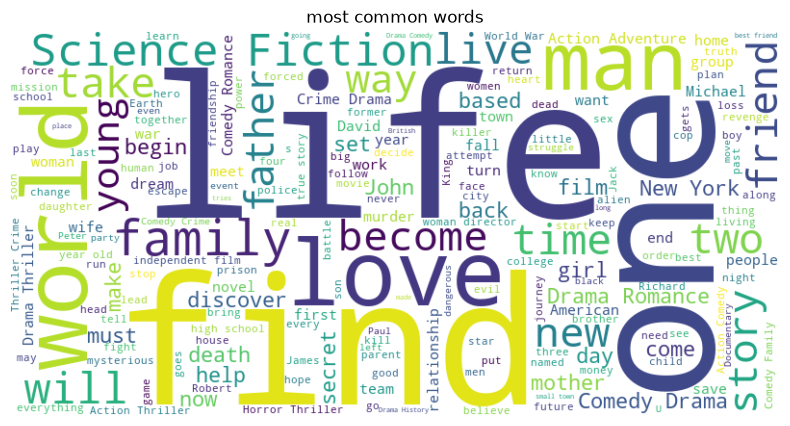

In [60]:
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title("most common words")
plt.show()

In [61]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [62]:
stop_words=set(stopwords.words('english'))

In [63]:
def preprocessing(text):
    text=re.sub(r"[^a-zA-Z\s]"," ",text)
    text=text.lower()
    tokens = word_tokenize(text)
    tokens=[word for word in tokens if word not in stop_words]
    return " ".join(tokens)
    
    

In [64]:
movie_data = movie_data.apply(preprocessing)

In [65]:
vectorizer=TfidfVectorizer(max_features=5000)
vector=vectorizer.fit_transform(movie_data)

In [66]:
print(vector)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 186454 stored elements and shape (4803, 5000)>
  Coords	Values
  (0, 26)	0.06472794489913196
  (0, 53)	0.07416360855473277
  (0, 1599)	0.09234340782242743
  (0, 3959)	0.08614150150577407
  (0, 1641)	0.08624070469322845
  (0, 1045)	0.16256516160670426
  (0, 824)	0.16801972084968414
  (0, 1786)	0.11999633074855637
  (0, 4202)	0.2622073857877162
  (0, 4822)	0.0932284697426224
  (0, 880)	0.18788644431979112
  (0, 4168)	0.14456070651202618
  (0, 3109)	0.1950179361426651
  (0, 719)	0.13529376167060178
  (0, 2811)	0.1547454901608183
  (0, 3016)	0.15600998062705443
  (0, 3296)	0.4021666890698053
  (0, 4694)	0.16801972084968414
  (0, 2983)	0.11832822194513679
  (0, 384)	0.10624922909092875
  (0, 4564)	0.15733617746074746
  (0, 1704)	0.15020468563787348
  (0, 3247)	0.17485085996801328
  (0, 3560)	0.18059458835512876
  (0, 112)	0.1327030743706726
  :	:
  (4802, 3197)	0.10281714649077103
  (4802, 1311)	0.17726634776911024
  (4802, 539)	

getting cosin score using cosinesimilarity

In [67]:
similarity=cosine_similarity(vector,vector)

In [68]:
print(similarity)

[[1.         0.0340031  0.02481268 ... 0.00575398 0.02201562 0.        ]
 [0.0340031  1.         0.02888573 ... 0.02851127 0.02012793 0.00356417]
 [0.02481268 0.02888573 1.         ... 0.01338183 0.04928611 0.00389072]
 ...
 [0.00575398 0.02851127 0.01338183 ... 1.         0.01902692 0.05719246]
 [0.02201562 0.02012793 0.04928611 ... 0.01902692 1.         0.02098909]
 [0.         0.00356417 0.00389072 ... 0.05719246 0.02098909 1.        ]]


In [69]:
similarity.shape

(4803, 4803)

function for recommadation

In [70]:
def recommend(movie_name,similarity=similarity,df=data, top_n=10):
    indx=data[data['title'].str.lower()==movie_name.lower()].index
    if len(indx)==0:
        return "movie not found! in dataset"
    indx=indx[0]
    similarity_score=sorted(list(enumerate(similarity[indx])),key= lambda x:x[1],reverse=True)
    similarity_score=similarity_score[1:top_n+1]

    movie_index=[i[0] for i in similarity_score]
    return df[['title','tagline','overview']].iloc[movie_index]
    


In [71]:
recommend('avatar')

,title,tagline,overview
1531,Moonraker,Outer space now belongs to 007.,During the transportation of a Space Shuttle a...
461,Lost in Space,"Danger, Will Robinson!",The prospects for continuing life on Earth in ...
3158,Alien,In space no one can hear you scream.,"During its return to the earth, commercial spa..."
1914,Lifeforce,"In the blink of an eye, the terror begins.",A space shuttle mission investigating Halley's...
2403,Aliens,This Time It's War,When Ripley's lifepod is found by a salvage cr...
94,Guardians of the Galaxy,All heroes start somewhere.,"Light years from Earth, 26 years after being a..."
3730,Cargo,,The story of CARGO takes place on rusty space-...
1354,Space Chimps,"Houston, we have a problem!",Circus monkey Ham III works in a circus where ...
2198,Lockout,Take no prisoners.,"Set in the near future, Lockout follows a fals..."
1341,The Inhabited Island,,"On the threshold of 22nd century, furrowing th..."
